# Scores plot

The scores plot draws each observation as a point in the space of two components, with crosshairs at the origin and, when we ask for it, one color per class.

    plot_scores(scores; group = ..., comps = (1, 2), kwargs...)

It takes a scores matrix — observations in rows, components in columns — so anything that produces scores can be drawn with it: PCA, PLS, CCA, JIVE. It never sees the model itself.

We simulate a small data set, fit a PCA, look at the default plot, and then build it up.

## Setup

In [2]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs


## A simulated example

Three latent signals drive twenty variables, plus a little noise. We read the class label off the first signal, so the observations fall into three groups that PCA should separate along the first component.

The same simulation runs through the other notebooks, so the figures are comparable across plots.

In [3]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

# the class is read off the first latent signal
y = [latent[i, 1] > 0.4 ? "a" : latent[i, 1] < -0.4 ? "c" : "b" for i in 1:n]

m = pca(X; k = 5)
S = pca_transform(m, X)

size(S)   # observations by components

(90, 5)

## The default plot

Given nothing but the scores, we get the first two components, generic axis labels, and crosshairs marking zero. We passed no grouping, so every observation sits in one series and there is no legend to draw.

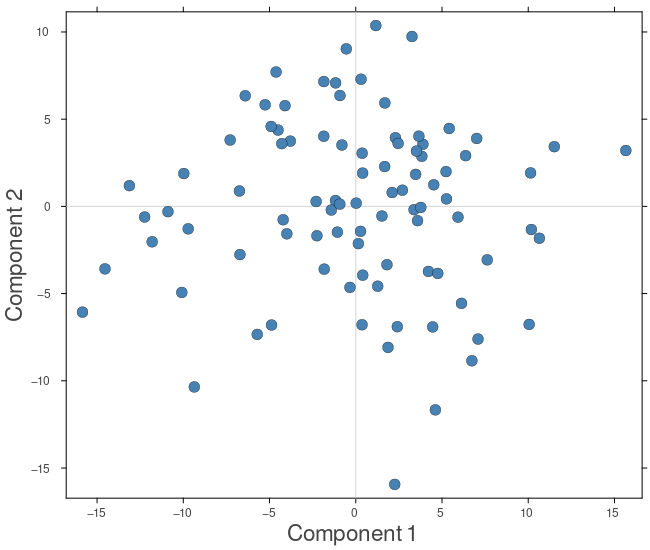

In [4]:
plot_scores(S)

---

# Modifying the plot

Two arguments change **what we draw** — `group` and `comps`. Everything else changes how it looks: `origincolor` for the crosshairs, and the whole standard `Plots` vocabulary for the rest. Anything the plot sets for itself is a default that yields to whatever we pass.

## Grouping the observations

`group` splits the observations into one series per level, which gives us categorical colors and one legend entry per class rather than the continuous colorbar a `marker_z` would produce. The legend appears on its own once there is more than one level, and its text comes straight from the vector we pass — so relabelling the vector relabels the legend.

Here we also name the axes properly and give the figure a title.

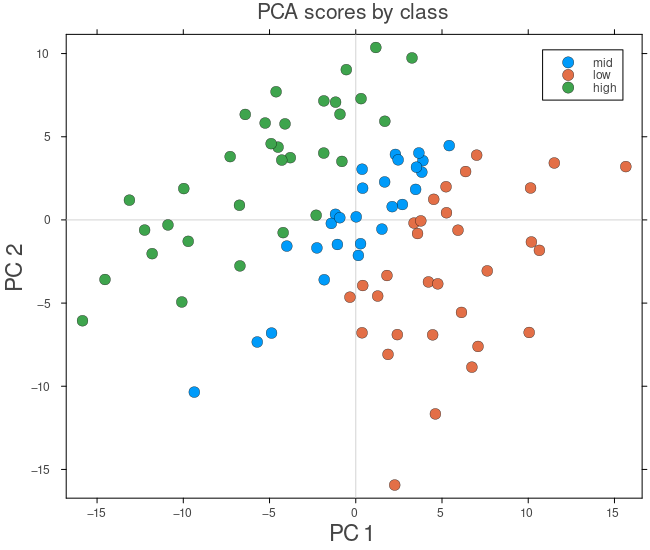

In [29]:
plot_scores(S;
            group  = replace(y, "a" => "low", "b" => "mid", "c" => "high"),
            xlabel = "PC 1",
            ylabel = "PC 2",
            title  = "PCA scores by class")

## Choosing components, and restyling

`comps` picks any other pair of components. The axis labels do not follow it, so when we move off the first two we say so ourselves.

This is also where the styling options stack up. Below we change the pair of components, redden the crosshairs with `origincolor`, enlarge the markers, move the legend inside the axes, and shrink the canvas — all in one call.

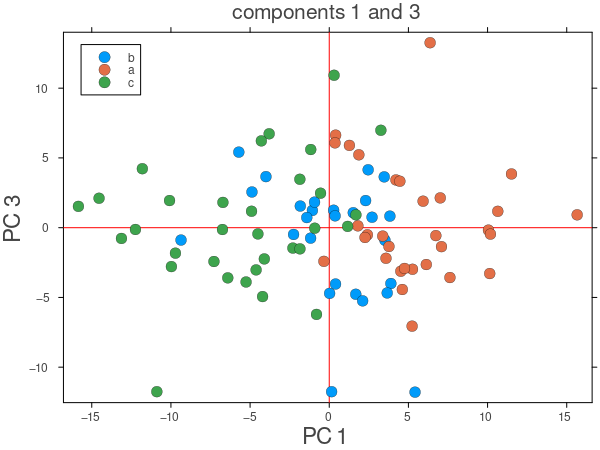

In [6]:
plot_scores(S;
            group       = y,
            comps       = (1, 3),
            xlabel      = "PC 1",
            ylabel      = "PC 3",
            title       = "components 1 and 3",
            origincolor = :red,
            marker      = 10,
            legend      = :topleft,
            size        = (600, 450))

## Without a legend, on a wide canvas

When the grouping is obvious from context, or when the figure is going into a paper with its own caption, we drop the legend and reshape the canvas.

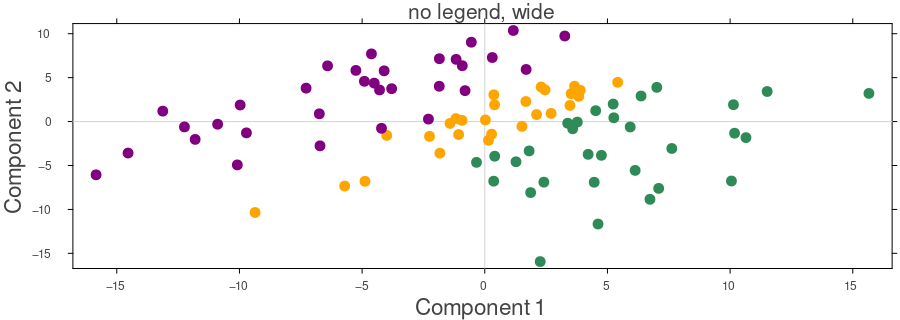

In [33]:
plot_scores(S;
            group             = y,
            legend            = false,
            marker            = 4,
            markerstrokewidth = 0,
            size              = (900, 320), 
            palette = [:orange, :seagreen, :purple],
            left_margin        = (5,:mm),
            bottom_margin        = (5,:mm),
            title             = "no legend, wide")